In [10]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Load preprocessed + clustered data (already has Age, Total_Spending, Cluster, etc.)
df = pd.read_csv('../data/preprocessed/david_clustered.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Shape: (2225, 40)
Columns: ['ID', 'Education', 'Income', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Living_With', 'Children_at_home', 'Family_Size', 'Total_Spending', 'Total_Purchases', 'Pct_Fruits', 'Pct_Sweet', 'Pct_Wine', 'Pct_Meat', 'Pct_Gold', 'Pct_Fish', 'Pct_WebPurchases', 'Pct_CatalogPurchases', 'Pct_StorePurchases', 'Cluster']


,ID,Education,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Pct_Fruits,Pct_Sweet,Pct_Wine,Pct_Meat,Pct_Gold,Pct_Fish,Pct_WebPurchases,Pct_CatalogPurchases,Pct_StorePurchases,Cluster
0,5524,Graduate,58138.0,2012-09-04,58,635,88,546,172,88,...,0.054422,0.054422,0.392703,0.337662,0.054422,0.106370,0.363636,0.454545,0.181818,2
1,2174,Graduate,46344.0,2014-03-08,38,11,1,6,2,1,...,0.037037,0.037037,0.407407,0.222222,0.222222,0.074074,0.250000,0.250000,0.500000,3
2,4141,Graduate,71613.0,2013-08-21,26,426,49,127,111,21,...,0.063144,0.027062,0.548969,0.163660,0.054124,0.143041,0.400000,0.100000,0.500000,2


## 1. CLV Model — RFM-Based Prediction

**Target:** Total_Spending (Monetary — raw dollars)

**Features:** Recency + Total_Purchases (Frequency) — classic RFM framework

The model learns: "given how recently and how often someone buys, how much do they spend?"

In [11]:
# Target: CLV proxy (total spending in real dollars)
y = df['Total_Spending']

# Features: Recency (R) + Frequency (F) only — Monetary (M) is the target
numeric_features = ['Recency', 'Total_Purchases']
categorical_features = []

X = df[numeric_features]

print(f"Target (Total_Spending): ${y.mean():.0f} avg, ${y.min():.0f}-${y.max():.0f} range")
print(f"Features: {numeric_features}")
print(f"\nRecency:         {df['Recency'].mean():.0f} avg days")
print(f"Total_Purchases: {df['Total_Purchases'].mean():.1f} avg purchases")

Target (Total_Spending): $607 avg, $8-$2525 range
Features: ['Recency', 'Total_Purchases']

Recency:         49 avg days
Total_Purchases: 12.6 avg purchases


## 2. Cross-Validation — Compare Models

In [12]:
# Preprocessor — just scaling (no categoricals)
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
])

# Three models to compare
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

print('=== 5-FOLD CROSS-VALIDATION ===\n')
for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    cv_results = cross_validate(pipe, X, y, cv=5,
                                scoring=['r2', 'neg_mean_absolute_error'],
                                return_train_score=True)
    print(f'{name}:')
    print(f'  R² (test):  {cv_results["test_r2"].mean():.3f} ± {cv_results["test_r2"].std():.3f}')
    print(f'  MAE (test): ${abs(cv_results["test_neg_mean_absolute_error"].mean()):.2f}')
    print()

=== 5-FOLD CROSS-VALIDATION ===

Linear Regression:
  R² (test):  0.672 ± 0.029
  MAE (test): $243.72

Random Forest:
  R² (test):  0.628 ± 0.025
  MAE (test): $218.68

Gradient Boosting:
  R² (test):  0.690 ± 0.019
  MAE (test): $215.72



## 3. Best Model — Test Set Evaluation & Feature Importance

=== BEST MODEL (Gradient Boosting) on TEST SET ===
R²:  0.688
MAE: $218.41


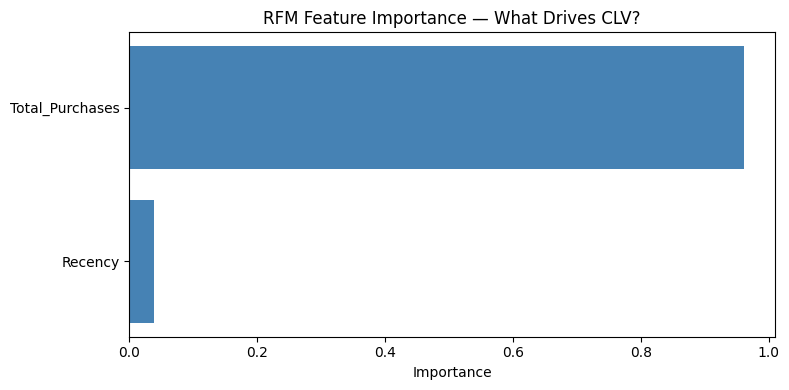


Frequency (Total_Purchases) importance: 0.961
Recency importance: 0.039


In [13]:
import matplotlib.pyplot as plt

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=100, random_state=42))
])
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

print(f'=== BEST MODEL (Gradient Boosting) on TEST SET ===')
print(f'R²:  {r2_score(y_test, y_pred):.3f}')
print(f'MAE: ${mean_absolute_error(y_test, y_pred):.2f}')

# Feature importance (just R and F)
importances = best_pipe.named_steps['model'].feature_importances_
feat_imp = pd.DataFrame({'Feature': numeric_features, 'Importance': importances}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('RFM Feature Importance — What Drives CLV?')
plt.tight_layout()
plt.show()

print(f'\nFrequency (Total_Purchases) importance: {importances[1]:.3f}')
print(f'Recency importance: {importances[0]:.3f}')

## 4. Predicted CLV by Cluster

=== PREDICTED CLV BY CLUSTER ===
         count  avg_predicted_clv  avg_actual_spend  avg_income  response_rate
Cluster                                                                       
0          470             226.45            179.66    31975.87           0.11
1          618             756.19            646.70    52512.46           0.18
2          566            1067.27           1285.52    73708.30           0.27
3          571             311.31            241.72    45263.58           0.04


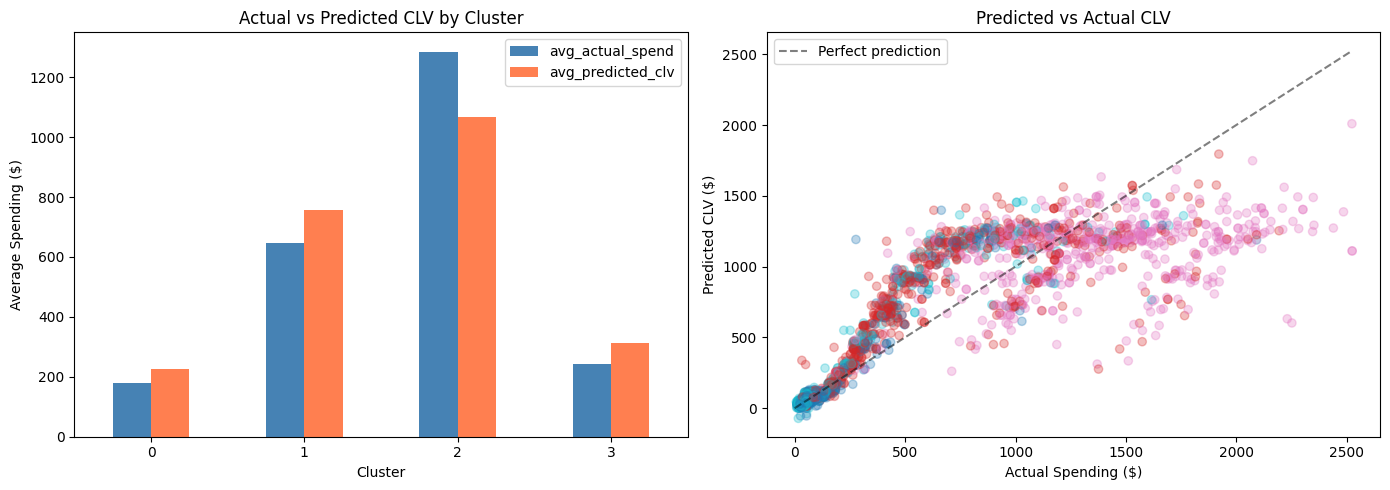

In [14]:
# Predict CLV for all customers (using clusters from david_kmeans_clustering)
df['Predicted_CLV'] = best_pipe.predict(X)

print('=== PREDICTED CLV BY CLUSTER ===')
clv_by_cluster = df.groupby('Cluster').agg(
    count=('Predicted_CLV', 'count'),
    avg_predicted_clv=('Predicted_CLV', 'mean'),
    avg_actual_spend=('Total_Spending', 'mean'),
    avg_income=('Income', 'mean'),
    response_rate=('Response', 'mean')
).round(2)
print(clv_by_cluster)

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

clv_by_cluster[['avg_actual_spend', 'avg_predicted_clv']].plot(kind='bar', ax=ax1, color=['steelblue', 'coral'])
ax1.set_title('Actual vs Predicted CLV by Cluster')
ax1.set_ylabel('Average Spending ($)')
ax1.set_xlabel('Cluster')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# Scatter: predicted vs actual
ax2.scatter(df['Total_Spending'], df['Predicted_CLV'], alpha=0.3, c=df['Cluster'], cmap='tab10')
ax2.plot([0, df['Total_Spending'].max()], [0, df['Total_Spending'].max()], 'k--', alpha=0.5, label='Perfect prediction')
ax2.set_xlabel('Actual Spending ($)')
ax2.set_ylabel('Predicted CLV ($)')
ax2.set_title('Predicted vs Actual CLV')
ax2.legend()

plt.tight_layout()
plt.show()